/Users/rbrady0110/micromamba/envs/doubles/lib/python3.13/site-packages/lenstronomy/Data/psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(
/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_24774/932095541.py:32: RuntimeWarning: invalid value encountered in log10
  im_psf = ax[0].imshow(np.log10(kernel_psf_class), cmap='coolwarm', origin='lower')


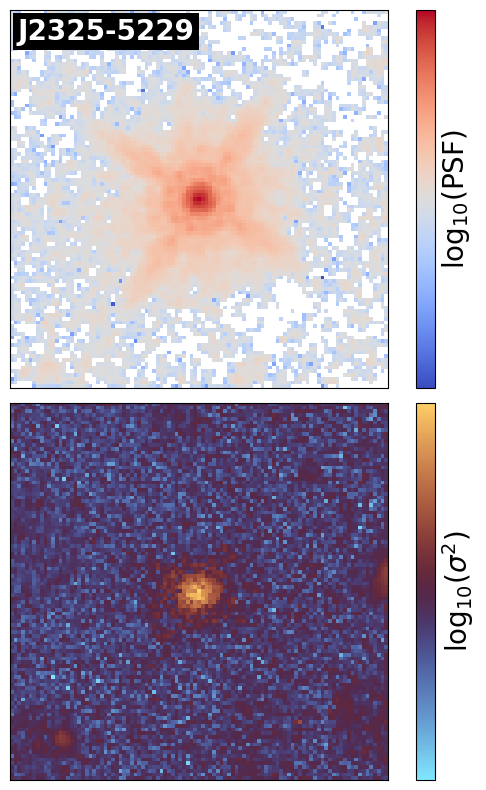

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import kernel_util

filt = 'F160W'
name = "J2325-5229"

fig, ax = plt.subplots(2, 1, figsize=(6, 8))  # 2 rows, 1 column
fontsize = 20

# Load PSF
psf_file = f'../../cutout_data/{name}/{filt}/outputs/full_PSF.fits'
kernel = pyfits.getdata(psf_file)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 301

kernel_cut = kernel_util.cut_psf(kernel, kernel_size)
kwargs_psf3 = {'psf_type': psf_type, 'kernel_point_source': kernel_cut, 
              'point_source_supersampling_factor': 3, 
              }

psf_class = PSF(**kwargs_psf3)
kernel_psf_class = psf_class.kernel_point_source

# Load variance map
error_map = np.loadtxt(f'../../cutout_data/{name}/{filt}/psf_variance.txt')
var_array = np.array(error_map)

# Top: PSF
im_psf = ax[0].imshow(np.log10(kernel_psf_class), cmap='coolwarm', origin='lower')
cbar_psf = fig.colorbar(im_psf, ax=ax[0])
cbar_psf.set_label(r'log$_{10}$(PSF)', fontsize=fontsize)
cbar_psf.set_ticks([])

# Bottom: PSF variance
im_var = ax[1].imshow(np.log10(var_array), cmap='managua_r', origin='lower')
cbar_var = fig.colorbar(im_var, ax=ax[1])
cbar_var.set_label(r'log$_{10}$($\sigma^2$)', fontsize=fontsize)
cbar_var.set_ticks([])

# Remove ticks
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

# Label system name on PSF panel
ax[0].text(
    0.02, 0.98, name,
    transform=ax[0].transAxes,
    fontsize=fontsize,
    color='white',
    fontweight='bold',
    va='top',
    ha='left',
    bbox=dict(facecolor='black', alpha=1.0, edgecolor='none', pad=3)
)

plt.tight_layout()
#plt.savefig('psf_ir.png')
plt.show()
